# **PHASE 1: LOAD DATASET**

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal.windows import tukey
from scipy.interpolate import interp1d
from scipy.ndimage import label
from time import perf_counter

In [2]:
# ============================================================
# Load S21 Dataset
# ============================================================

DATASET_DIR = Path("datasets")

with open(DATASET_DIR/"fd_data_s21_adi (1).pickle", "rb") as f:
    s21 = pickle.load(f)

print("Shape :", s21.shape)
print("Type  :", s21.dtype)

Shape : (505, 1001, 72)
Type  : complex128


In [3]:
# ============================================================
# Dataset Integrity Check
# ============================================================

assert np.iscomplexobj(s21), "Dataset NOT complex"
assert np.all(np.isfinite(s21)), "There are NaN or Inf"

print("Dataset OK")

Dataset OK


# **PHASE 2: METADATA CLEANING + PARSING + PHANTOM DATABASE MERGE**

In [4]:
# ============================================================
# Load Metadata
# ============================================================

metadata = pd.read_pickle(DATASET_DIR/"metadata_gen_two.pickle")
metadata = pd.DataFrame(metadata)

print("Metadata :", metadata.shape)

Metadata : (1301, 22)


In [5]:
# ============================================================
# Load Phantom Database
# ============================================================

phantom_db = pd.read_csv(DATASET_DIR/"phantom_database.csv")

n_unique = phantom_db["phantom_id"].nunique()
print("Phantom DB    :", phantom_db.shape)
print("Unique phantom:", n_unique, "(expected 66, only", n_unique, "survived cleaning)")

Phantom DB    : (59, 10)
Unique phantom: 59 (expected 66, only 59 survived cleaning)


In [6]:
# ============================================================
# Clean Metadata
# ============================================================

metadata = metadata.copy()

metadata["phant_id"] = (
    metadata["phant_id"].astype(str).str.strip()
)

metadata = metadata[metadata["phant_id"] != ""]

In [7]:
# ============================================================
# Merge Metadata & Phantom Database
# ============================================================

physical_model = metadata.merge(
    phantom_db,
    left_on="phant_id",
    right_on="phantom_id",
    how="left"
)

print("Merged :", physical_model.shape)
print("Rows with no phantom match:", physical_model["shell_radius"].isna().sum())

Merged : (1149, 32)
Rows with no phantom match: 285


# **PHASE 3: PHYSICAL MODEL**

In [8]:
# ============================================================
# Tissue Fractions
# ============================================================

physical_model["fat_volume"] = (
    physical_model["shell_volume"] - physical_model["fib_volume"]
)
physical_model["fat_fraction"] = (
    physical_model["fat_volume"] / physical_model["shell_volume"]
)
physical_model["fib_fraction"] = (
    physical_model["fib_volume"] / physical_model["shell_volume"]
)

In [9]:
# ============================================================
# Rename Useful Columns
# ============================================================

physical_model = physical_model.rename(columns={
    "shell_radius":"breast_radius_mm",
    "tum_rad":"tumor_radius_mm",
    "tum_x":"tumor_x_mm",
    "tum_y":"tumor_y_mm",
})

In [10]:
# ============================================================
# Tumor Coordinate Unit Check (cm -> mm)
# ============================================================
# UM-BMID tumor radii are 5/10/15/20mm per the paper. If the raw
# column max is < 2.0, the values are actually in cm and must be
# scaled to mm so they're consistent with breast_radius_mm and grid.

if physical_model["tumor_radius_mm"].max() < 2.0:
    print("Tumor columns detected in cm -> converting to mm")
    physical_model["tumor_radius_mm"] = physical_model["tumor_radius_mm"]*10.0
    physical_model["tumor_x_mm"] = physical_model["tumor_x_mm"]*10.0
    physical_model["tumor_y_mm"] = physical_model["tumor_y_mm"]*10.0
else:
    print("Tumor columns already in mm")

print(physical_model[["tumor_radius_mm","tumor_x_mm","tumor_y_mm"]].describe())

Tumor columns detected in cm -> converting to mm
       tumor_radius_mm  tumor_x_mm  tumor_y_mm
count       504.000000  504.000000  504.000000
mean          9.861111    1.161706   -7.890873
std           3.884587   18.660409   25.417371
min           5.000000  -37.500000  -52.500000
25%           5.000000  -12.500000  -25.000000
50%          10.000000    5.000000   -7.500000
75%          15.000000   17.500000   13.125000
max          15.000000   37.500000   52.500000


In [11]:
# ============================================================
# Adaptive Effective Permittivity & Wave Velocity
# ============================================================

EPS_FAT = 7.0        # glycerin mixture
EPS_FIB = 45.0        # Triton X-100 mixture
C_LIGHT = 3e8

physical_model["eps_eff"] = (
    physical_model["fat_fraction"]*EPS_FAT
    + physical_model["fib_fraction"]*EPS_FIB
)

physical_model["wave_velocity"] = (
    C_LIGHT / np.sqrt(physical_model["eps_eff"])
)

In [12]:
# ============================================================
# Per-Phantom Antenna Ring Radius (Correction #2: geometry limitation)
# ============================================================
# The scan-rig radius is NOT identical for every phantom scan --
# metadata_gen_two carries a per-record 'ant_rad' field. Using one
# hardcoded mean radius for every phantom biases the delay grid and
# is a likely contributor to the large error seen even in synthetic
# tests. Pull it per-phantom instead, with a safe fallback.

FALLBACK_ANTENNA_RADIUS_MM = 215.0  # UM-BMID paper spec, used only if metadata lacks the field

_ant_rad_col = None
for _cand in ["ant_rad", "antenna_radius", "ant_radius"]:
    if _cand in metadata.columns:
        _ant_rad_col = _cand
        break

if _ant_rad_col is not None:
    physical_model["antenna_radius_mm"] = pd.to_numeric(
        physical_model[_ant_rad_col], errors="coerce"
    )
    _median = physical_model["antenna_radius_mm"].median()
    if pd.notna(_median) and _median < 100:
        # values are in cm -> convert to mm
        physical_model["antenna_radius_mm"] *= 10.0
    physical_model["antenna_radius_mm"] = physical_model["antenna_radius_mm"].fillna(
        FALLBACK_ANTENNA_RADIUS_MM
    )
    print(f"Per-phantom antenna radius loaded from metadata column '{_ant_rad_col}'")
else:
    physical_model["antenna_radius_mm"] = FALLBACK_ANTENNA_RADIUS_MM
    print("No per-phantom antenna radius column found -- using fixed fallback for all phantoms")

print(physical_model["antenna_radius_mm"].describe())


Per-phantom antenna radius loaded from metadata column 'ant_rad'
count    1149.000000
mean      218.772846
std         4.719456
min       210.000000
25%       220.000000
50%       220.000000
75%       220.000000
max       230.000000
Name: antenna_radius_mm, dtype: float64


In [13]:
# ============================================================
# Tumor-Only Subset (s21 has 505 scans ~ 504 tumor-labelled rows)
# ============================================================
# gt x/y/radius must all be present, AND the phantom must have
# actually survived phantom_database.csv cleaning (only 59/66 did),
# otherwise breast_radius_mm / wave_velocity are NaN.

tumor_model = physical_model[
    physical_model["tumor_radius_mm"].notna() &
    physical_model["tumor_x_mm"].notna() &
    physical_model["tumor_y_mm"].notna() &
    physical_model["breast_radius_mm"].notna() &
    physical_model["wave_velocity"].notna()
].reset_index(drop=True)

N_VALID_SCANS = min(len(tumor_model), s21.shape[0])

print("tumor_model rows :", len(tumor_model))
print("s21 scans        :", s21.shape[0])
print("Usable scan_idx range : 0 ..", N_VALID_SCANS-1)

tumor_model rows : 432
s21 scans        : 505
Usable scan_idx range : 0 .. 431


# **PHASE 4: RECONSTRUCTION SETUP**

In [14]:
# ============================================================
# Frequency & Time Axis
# ============================================================

N_FREQ = s21.shape[1]

F_START = 2e9
F_STOP  = 9e9

frequency = np.linspace(F_START, F_STOP, N_FREQ)

delta_f = frequency[1] - frequency[0]
delta_t = 1 / (N_FREQ * delta_f)
time = np.arange(N_FREQ) * delta_t

print("Bandwidth :", (frequency[-1]-frequency[0])/1e9, "GHz")
print("Max Time  :", time[-1]*1e9, "ns")

Bandwidth : 7.0 GHz
Max Time  : 142.71442842871417 ns


In [15]:
# ============================================================
# Antenna / Scan Geometry (Fixed Hardware, NOT Per-Phantom)
# ============================================================
# Bistatic: 2 antennas, 60 deg apart, mounted on one rotating
# platform, measured at 72 equally-spaced positions on a circular
# trajectory. Trajectory radius (20-23cm in UM-BMID) is a property
# of the SCAN RIG, not the breast phantom -- it must NOT be confused
# with breast_radius_mm (imaging-domain size, per phantom).
# phantom_database.csv has no trajectory-radius column, so it is
# hardcoded from the UM-BMID paper spec.

N_POSITIONS = s21.shape[2]           # 72 rotation positions
TRAJECTORY_RADIUS_MM = 215.0          # hardcoded, 21.5 cm
SEPARATION_DEG = 60.0                 # fixed Tx-Rx angular offset

pos_angles = np.linspace(0, 2*np.pi, N_POSITIONS, endpoint=False)

antenna_geometry = pd.DataFrame({
    "position_id": np.arange(N_POSITIONS),
    "theta_deg": np.degrees(pos_angles),
    "x_mm": TRAJECTORY_RADIUS_MM*np.cos(pos_angles),
    "y_mm": TRAJECTORY_RADIUS_MM*np.sin(pos_angles)
})

sep_steps = int(round(SEPARATION_DEG/360.0*N_POSITIONS))

channel_map = pd.DataFrame({
    "channel": np.arange(N_POSITIONS),
})
channel_map["tx"] = channel_map["channel"]
channel_map["rx"] = (channel_map["channel"] + sep_steps) % N_POSITIONS

print("Positions            :", N_POSITIONS)
print("Trajectory radius(mm):", TRAJECTORY_RADIUS_MM)
print("Tx-Rx separation(deg):", SEPARATION_DEG, "->", sep_steps, "steps")
display(channel_map.head())

Positions            : 72
Trajectory radius(mm): 215.0
Tx-Rx separation(deg): 60.0 -> 12 steps


,channel,tx,rx
0,0,0,12
1,1,1,13
2,2,2,14
3,3,3,15
4,4,4,16


# **PHASE 5: SINGLE-SCAN RECONSTRUCTION PIPELINE**

In [16]:
# ============================================================
# Reconstruction Utility Functions
# ============================================================

def align_channels(signal_scan, delay_grid, time):
    n_channel = signal_scan.shape[1]
    npix = delay_grid.shape[1]
    aligned = np.zeros((n_channel, npix), dtype=complex)
    for ch in range(n_channel):
        interp_real = interp1d(time, signal_scan[:,ch].real,
                                bounds_error=False, fill_value=0.0)
        interp_imag = interp1d(time, signal_scan[:,ch].imag,
                                bounds_error=False, fill_value=0.0)
        aligned[ch] = interp_real(delay_grid[ch]) + 1j*interp_imag(delay_grid[ch])
    return aligned

def beamform_das(aligned):
    return np.abs(aligned.sum(axis=0)) / aligned.shape[0]

def beamform_dmas(aligned):
    sum_s = aligned.sum(axis=0)
    sum_s2 = (aligned**2).sum(axis=0)
    return np.abs(0.5*(sum_s**2 - sum_s2))

def mer_enhance(img, power=2.0):
    norm = img / (img.max() + 1e-12)
    return norm**power

def gamma_correction(img, gamma=0.5):
    norm = img / (img.max() + 1e-12)
    return norm**gamma

def select_tvsvd_rank_adaptive(S, min_rank=1, max_energy=0.98):
    # Kneedle elbow detection on the cumulative-energy curve: the
    # rank to remove is the point of maximum perpendicular distance
    # from the straight line joining the curve's endpoints. Falls
    # back to a fixed 90% energy cut if the curve is too flat/short
    # to have a clear knee.
    energy = S**2
    cum = np.cumsum(energy) / np.sum(energy)
    n = len(cum)
    if n < 3:
        return max(min_rank, int(np.argmax(cum >= 0.90)))

    x = np.arange(n)
    x_norm = x / (n-1)
    y_norm = cum

    p1 = np.array([x_norm[0], y_norm[0]])
    p2 = np.array([x_norm[-1], y_norm[-1]])
    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)

    if line_len < 1e-12:
        return max(min_rank, int(np.argmax(cum >= 0.90)))

    line_unit = line_vec / line_len
    pts = np.stack([x_norm, y_norm], axis=1) - p1
    proj_len = pts @ line_unit
    proj_pts = np.outer(proj_len, line_unit)
    dist = np.linalg.norm(pts - proj_pts, axis=1)

    knee = int(np.argmax(dist))
    knee = max(min_rank, knee)

    # never remove past max_energy worth of components
    hard_cap = int(np.argmax(cum >= max_energy))
    return min(knee, hard_cap) if hard_cap > 0 else knee

def select_blob_threshold_adaptive(img):
    # Otsu-style adaptive threshold: try skimage, fall back to a
    # percentile-based heuristic if skimage isn't available.
    try:
        from skimage.filters import threshold_otsu
        return threshold_otsu(img)
    except Exception:
        return np.percentile(img, 90)

In [17]:
# ============================================================
# reconstruct_scan(scan_idx) -- Fully Self-Contained Per Scan
# ============================================================
# Takes ONLY scan_idx. Everything else (breast_radius_mm,
# wave_velocity, delay_grid, images...) is local to the call,
# never a leaked global -- re-derived fresh every time.
#
# adaptive_tvsvd / adaptive_threshold: per-scan elbow / Otsu
# selection instead of one fixed constant for every phantom.
# return_diagnostics: also returns the intermediate arrays needed
# to reproduce every plot from the original notebook (windowing,
# raw time signal, singular-value spectrum, delay heatmap, ...)
# without duplicating the pipeline logic anywhere else.

def reconstruct_scan(scan_idx, nx=120, ny=120,
                      adaptive_tvsvd=True, tsvd_energy=0.90,
                      adaptive_threshold=True, blob_threshold=0.7,
                      return_diagnostics=False):

    if scan_idx < 0 or scan_idx >= N_VALID_SCANS:
        raise ValueError(f"scan_idx {scan_idx} out of range [0,{N_VALID_SCANS-1}]")

    t_start = perf_counter()

    scan_params = tumor_model.iloc[scan_idx]
    breast_radius_mm = scan_params["breast_radius_mm"]
    wave_velocity = scan_params["wave_velocity"]

    # ---- 4.1 Complex IFFT ----
    window = tukey(s21.shape[1], alpha=0.25)
    s21_window = s21[scan_idx] * window[:,None]
    time_signal = np.fft.ifft(s21_window, axis=0)
    rms = np.sqrt(np.mean(np.abs(time_signal)**2, axis=0, keepdims=True))
    time_signal = time_signal / (rms + 1e-12)

    channel_energy = np.mean(np.abs(time_signal)**2, axis=0)

    # ---- 4.2 Bent-Ray TOF (bistatic, per-scan velocity) ----
    x_axis = np.linspace(-breast_radius_mm, breast_radius_mm, nx)
    y_axis = np.linspace(-breast_radius_mm, breast_radius_mm, ny)
    grid_x, grid_y = np.meshgrid(x_axis, y_axis)
    grid_x_flat = grid_x.ravel()
    grid_y_flat = grid_y.ravel()

    ant_x = antenna_geometry["x_mm"].values
    ant_y = antenna_geometry["y_mm"].values
    tx_idx = channel_map["tx"].values
    rx_idx = channel_map["rx"].values

    dist_tx_mm = np.sqrt((grid_x_flat[None,:]-ant_x[tx_idx,None])**2
                          + (grid_y_flat[None,:]-ant_y[tx_idx,None])**2)
    dist_rx_mm = np.sqrt((grid_x_flat[None,:]-ant_x[rx_idx,None])**2
                          + (grid_y_flat[None,:]-ant_y[rx_idx,None])**2)

    delay_grid = ((dist_tx_mm+dist_rx_mm)/1000) / wave_velocity

    # ---- 4.4 TVSVD (adaptive rank per scan) ----
    U, S, Vt = np.linalg.svd(time_signal, full_matrices=False)

    if adaptive_tvsvd:
        remove = select_tvsvd_rank_adaptive(S)
    else:
        cum_energy = np.cumsum(S**2/np.sum(S**2))
        remove = int(np.argmax(cum_energy >= tsvd_energy))

    S_filtered = S.copy()
    S_filtered[:remove] = 0
    time_signal_tsvd = U @ np.diag(S_filtered) @ Vt

    # ---- 4.5-4.8 Beamforming ----
    aligned_raw = align_channels(time_signal, delay_grid, time)
    aligned_tsvd = align_channels(time_signal_tsvd, delay_grid, time)

    das_img = beamform_das(aligned_raw).reshape(ny,nx)
    dmas_img = beamform_dmas(aligned_raw).reshape(ny,nx)
    phase_dmas_img = beamform_dmas(aligned_tsvd).reshape(ny,nx)
    bent_phase_dmas_img = phase_dmas_img   # full stack = proposed

    # ---- Phase 5: Enhancement ----
    mer_img = mer_enhance(bent_phase_dmas_img)
    enhanced_img = gamma_correction(mer_img, gamma=0.5)

    if adaptive_threshold:
        thresh = select_blob_threshold_adaptive(enhanced_img)
    else:
        thresh = blob_threshold

    binary_mask = enhanced_img >= thresh
    labeled_mask, n_blobs = label(binary_mask)
    if n_blobs > 0:
        sizes = [(labeled_mask==i).sum() for i in range(1, n_blobs+1)]
        tumor_mask = labeled_mask == (np.argmax(sizes)+1)
    else:
        tumor_mask = binary_mask

    # ---- Peak = blob centroid, not raw argmax ----
    ys_c, xs_c = np.where(tumor_mask)
    if len(xs_c) > 0:
        weights = enhanced_img[ys_c, xs_c]
        peak_x_mm = np.average(x_axis[xs_c], weights=weights)
        peak_y_mm = np.average(y_axis[ys_c], weights=weights)
    else:
        fb = np.unravel_index(np.argmax(enhanced_img), enhanced_img.shape)
        peak_y_mm, peak_x_mm = y_axis[fb[0]], x_axis[fb[1]]

    gt_x_mm = scan_params["tumor_x_mm"]
    gt_y_mm = scan_params["tumor_y_mm"]
    gt_r_mm = scan_params["tumor_radius_mm"]

    localization_error_mm = np.sqrt((peak_x_mm-gt_x_mm)**2 + (peak_y_mm-gt_y_mm)**2)

    gt_mask = ((grid_x-gt_x_mm)**2 + (grid_y-gt_y_mm)**2) <= gt_r_mm**2
    intersection = np.logical_and(tumor_mask, gt_mask).sum()
    union = np.logical_or(tumor_mask, gt_mask).sum()
    iou = intersection/union if union > 0 else 0.0
    dice = (2*intersection)/(tumor_mask.sum()+gt_mask.sum()) if (tumor_mask.sum()+gt_mask.sum())>0 else 0.0

    signal_power = bent_phase_dmas_img[tumor_mask].mean() if tumor_mask.sum()>0 else 0
    clutter_power = bent_phase_dmas_img[~tumor_mask].mean()
    clutter_std = bent_phase_dmas_img[~tumor_mask].std()
    scr_db = 10*np.log10(signal_power/(clutter_power+1e-12))
    smr_db = 10*np.log10(signal_power/(bent_phase_dmas_img.mean()+1e-12))
    cnr = (signal_power-clutter_power)/(clutter_std+1e-12)
    peak_intensity = bent_phase_dmas_img.max()

    runtime_sec = perf_counter() - t_start

    result = {
        "scan_idx": scan_idx,
        "phant_id": scan_params["phant_id"],
        "breast_radius_mm": breast_radius_mm,
        "wave_velocity": wave_velocity,
        "tvsvd_rank_removed": remove,
        "blob_threshold_used": thresh,
        "x_axis": x_axis, "y_axis": y_axis,
        "images": {
            "das": das_img, "dmas": dmas_img,
            "phase_dmas": phase_dmas_img,
            "bent_phase_dmas": bent_phase_dmas_img,
            "mer": mer_img, "enhanced": enhanced_img,
            "tumor_mask": tumor_mask,
        },
        "peak_x_mm": peak_x_mm, "peak_y_mm": peak_y_mm,
        "gt_x_mm": gt_x_mm, "gt_y_mm": gt_y_mm, "gt_r_mm": gt_r_mm,
        "localization_error_mm": localization_error_mm,
        "iou": iou, "dice": dice,
        "scr_db": scr_db, "smr_db": smr_db, "cnr": cnr,
        "peak_intensity": peak_intensity,
        "runtime_sec": runtime_sec,
    }

    if return_diagnostics:
        result["diagnostics"] = {
            "window": window,
            "s21_window": s21_window,
            "time_signal": time_signal,
            "time_signal_tsvd": time_signal_tsvd,
            "channel_energy": channel_energy,
            "singular_values": S,
            "delay_grid": delay_grid,
        }

    return result

# **PHASE 5.5: 3-LAYER SNELL BENT-RAY MODEL, ADAPTIVE TVSVD, COHERENCE-FACTOR DMAS, LoG BLOB DETECTION, TIME GATING**

This phase replaces the placeholder straight-line / broken-V-shape TOF model with a genuine multi-interface bent-ray solver (Fermat's principle, which is equivalent to Snell's law at each interface), adds a per-scan hybrid TVSVD rank-selection rule that protects strong-but-non-uniform tumor components, adds a coherence-factor weighted DMAS image, an LoG-based blob detector, and pre-tissue time gating. `reconstruct_scan` (Phase 5) is left untouched as the V-Shape baseline for benchmarking; everything new lives in `reconstruct_scan_v2`.

In [18]:
# ============================================================
# Fermat-Principle Refraction Solver (vectorized golden-section search)
# ============================================================
# Finding the point B on a circular interface that a ray bends through
# is equivalent, by Fermat's principle, to minimizing the total travel
# time T(B) = |A-B|/v_out + |B-Target|/v_in over B's position on the
# circle. Minimizing T directly avoids solving the Snell equation with
# explicit surface normals and is trivial to vectorize over many
# (antenna, pixel) pairs at once via golden-section search.

def find_refraction_point(A_xy, T_xy, R_circle, v_out, v_in, n_iter=40):
    A_xy = np.asarray(A_xy, dtype=float)
    T_xy = np.asarray(T_xy, dtype=float)
    ang_a = np.arctan2(A_xy[..., 1], A_xy[..., 0])
    ang_t = np.arctan2(T_xy[..., 1], T_xy[..., 0])

    lo = np.minimum(ang_a, ang_t) - 0.75
    hi = np.maximum(ang_a, ang_t) + 0.75

    gr = (np.sqrt(5.0) - 1.0) / 2.0

    def travel_time(phi):
        bx = R_circle * np.cos(phi)
        by = R_circle * np.sin(phi)
        d1 = np.sqrt((bx - A_xy[..., 0])**2 + (by - A_xy[..., 1])**2)
        d2 = np.sqrt((bx - T_xy[..., 0])**2 + (by - T_xy[..., 1])**2)
        return d1 / v_out + d2 / v_in

    a, b = lo, hi
    c = b - gr * (b - a)
    d = a + gr * (b - a)
    fc = travel_time(c)
    fd = travel_time(d)

    for _ in range(n_iter):
        go_left = fc < fd
        b = np.where(go_left, d, b)
        a = np.where(go_left, a, c)
        c = b - gr * (b - a)
        d = a + gr * (b - a)
        fc = travel_time(c)
        fd = travel_time(d)

    phi_opt = 0.5 * (a + b)
    return np.stack([R_circle*np.cos(phi_opt), R_circle*np.sin(phi_opt)], axis=-1)


def _line_circle_length_fraction(P0, P1, C, R):
    # fraction of segment P0->P1 (per-row) that lies inside circle(C,R)
    d = P1 - P0
    f = P0 - C
    a = np.sum(d*d, axis=-1)
    b = 2.0*np.sum(f*d, axis=-1)
    c = np.sum(f*f, axis=-1) - R**2
    disc = b**2 - 4*a*c
    a_safe = np.where(a == 0, 1e-12, a)
    sq = np.sqrt(np.clip(disc, 0, None))
    t_lo = np.minimum((-b - sq)/(2*a_safe), (-b + sq)/(2*a_safe))
    t_hi = np.maximum((-b - sq)/(2*a_safe), (-b + sq)/(2*a_safe))
    t_enter = np.clip(t_lo, 0.0, 1.0)
    t_exit = np.clip(t_hi, 0.0, 1.0)
    valid = (disc >= 0) & (t_hi > 0) & (t_lo < 1)
    return np.where(valid, np.clip(t_exit - t_enter, 0.0, 1.0), 0.0)


In [19]:
# ============================================================
# Correction #1 & #6: True 3-Layer Bent-Ray Delay (Skin / Interior / Tumor)
# ============================================================
# Zone 1 (outer): air, v_air.
# Zone 2 (shell) : skin, thickness `skin_thickness_mm`, eps_skin.
# Zone 3 (core)  : interior effective medium (fat/fibro mix), v_interior.
# Zone 4 (local) : GT tumor disk, eps_tumor -- only applied when the
#                  straight segment from the skin/interior boundary to
#                  the pixel actually crosses the tumor, and only when
#                  use_gt_tumor_layer=True (upper-bound / calibration
#                  runs only -- inference must not see GT).
#
# The ray air->skin->interior is solved with a 3-iteration fixed-point
# scheme: refine the skin/interior bend point B2 given the current
# outer bend point B1, then refine B1 (air/skin interface) given the
# updated B2. Each sub-solve is an exact Fermat / Snell minimization on
# its own interface, so this converges to the physically-consistent
# bent path in a handful of iterations, replacing both the "broken
# straight-line V-shape" and the single-interface 2-layer shortcut.

def bent_ray_3layer_delay(ant_x, ant_y, grid_x_flat, grid_y_flat,
                           breast_radius_mm, skin_thickness_mm,
                           v_air, v_skin, v_interior, v_tumor,
                           gt_x_mm=None, gt_y_mm=None, gt_r_mm=None,
                           fixed_point_iters=3):
    n_ch = len(ant_x)
    n_px = len(grid_x_flat)
    R_outer = breast_radius_mm
    R_inner = max(breast_radius_mm - skin_thickness_mm, 1.0)

    P = np.stack([grid_x_flat, grid_y_flat], axis=-1)
    use_tumor_layer = gt_r_mm is not None and gt_r_mm > 0
    if use_tumor_layer:
        C = np.array([gt_x_mm, gt_y_mm])

    delay_grid = np.zeros((n_ch, n_px))

    for ch in range(n_ch):
        A = np.array([ant_x[ch], ant_y[ch]])
        A_b = np.broadcast_to(A, P.shape)

        # initial guess: 2-layer bend at the outer boundary only
        B1 = find_refraction_point(A_b, P, R_outer, v_air, v_interior)

        for _ in range(fixed_point_iters):
            B2 = find_refraction_point(B1, P, R_inner, v_skin, v_interior)
            B1 = find_refraction_point(A_b, B2, R_outer, v_air, v_skin)

        d_air = np.linalg.norm(B1 - A_b, axis=-1)
        d_skin = np.linalg.norm(B2 - B1, axis=-1)
        d_core_total = np.linalg.norm(P - B2, axis=-1)

        if use_tumor_layer:
            tumor_frac = _line_circle_length_fraction(B2, P, C, gt_r_mm)
        else:
            tumor_frac = np.zeros(n_px)

        d_tumor = d_core_total * tumor_frac
        d_interior_only = d_core_total - d_tumor

        t_air = (d_air / 1000.0) / v_air
        t_skin = (d_skin / 1000.0) / v_skin
        t_interior = (d_interior_only / 1000.0) / v_interior
        t_tumor = (d_tumor / 1000.0) / v_tumor

        delay_grid[ch] = t_air + t_skin + t_interior + t_tumor

    return delay_grid


In [20]:
# ============================================================
# Correction #5: Pre-Tissue Time Gating
# ============================================================
# Zero out samples that are still purely air-path propagation, i.e.
# before the earliest instant the direct wave could possibly have
# touched the breast surface. This trims the search space handed to
# TVSVD instead of relying on TVSVD alone to remove all clutter.

def apply_time_gate(time_signal, time_axis, ant_x, ant_y, tx_idx, rx_idx,
                     breast_radius_mm, v_air, guard_ns=0.05):
    dist_tx_air = np.sqrt(ant_x[tx_idx]**2 + ant_y[tx_idx]**2) - breast_radius_mm
    dist_rx_air = np.sqrt(ant_x[rx_idx]**2 + ant_y[rx_idx]**2) - breast_radius_mm
    t_gate = (dist_tx_air + dist_rx_air) / 1000.0 / v_air - guard_ns * 1e-9
    t_gate = np.clip(t_gate, 0, None)
    gate_idx = np.clip(np.searchsorted(time_axis, t_gate), 0, len(time_axis) - 1)

    gated = time_signal.copy()
    for ch in range(time_signal.shape[1]):
        gated[:gate_idx[ch], ch] = 0.0
    return gated


In [21]:
# ============================================================
# Correction #3: Hybrid TVSVD (Energy Elbow AND Spatial-Uniformity)
# ============================================================
# A component is only treated as skin clutter -- and removed -- if it
# is BOTH energetic (above the knee-selected rank AND above a minimum
# energy fraction) AND spatially uniform across channels (flatness of
# its Vt row close to 1, i.e. nearly identical loading on every
# channel, which is the signature of a skin reflection that a strong,
# off-center tumor return does not share). This prevents a strong
# tumor-bearing component from being discarded together with the
# skin clutter just because it also carries a lot of energy.

def select_tvsvd_rank_hybrid(S, Vt, energy_lower=0.01, flatness_thresh=0.85,
                              max_energy=0.98):
    knee = select_tvsvd_rank_adaptive(S, max_energy=max_energy)
    energy_frac = (S**2) / np.sum(S**2)

    remove_mask = np.zeros(len(S), dtype=bool)
    for k in range(knee):
        row = Vt[k]
        flatness = np.abs(np.mean(row)) / (np.sqrt(np.mean(row**2)) + 1e-12)
        if energy_frac[k] > energy_lower and flatness > flatness_thresh:
            remove_mask[k] = True
    return remove_mask


In [22]:
# ============================================================
# Correction #4: Coherence-Factor Weighted DMAS
# ============================================================
# CF(pixel) = |sum(aligned)|^2 / (N * sum(|aligned|^2)) in [0,1].
# Incoherent (noisy / clutter) pixels get pushed towards 0 even after
# amplitude alignment, while genuinely phase-coherent target pixels
# stay near 1 -- multiplying it into DMAS boosts CNR without changing
# where the peak sits.

def coherence_factor(aligned):
    n = aligned.shape[0]
    num = np.abs(aligned.sum(axis=0))**2
    den = n * (np.abs(aligned)**2).sum(axis=0)
    return num / (den + 1e-12)

def beamform_dmas_cf(aligned):
    return beamform_dmas(aligned) * coherence_factor(aligned)


In [23]:
# ============================================================
# Correction #4 (blob side): Laplacian-of-Gaussian Blob Detection
# ============================================================
# Static Otsu thresholding alone misses low-contrast tumors (threshold
# too high) or false-positives on noise (threshold too low). Running a
# multi-scale LoG filter first suppresses high-frequency noise and
# enhances round blob-shaped structures of tumor-like size before any
# thresholding is applied.

def select_blob_mask_log(img, sigma_list=(2, 3, 4, 5)):
    try:
        from scipy.ndimage import gaussian_laplace
        response = np.zeros_like(img)
        for s in sigma_list:
            blob_r = -gaussian_laplace(img, sigma=s) * (s**2)
            response = np.maximum(response, blob_r)
        response = response / (response.max() + 1e-12)
        thresh = select_blob_threshold_adaptive(response)
        binary_mask = response >= thresh
    except Exception:
        response = img
        thresh = select_blob_threshold_adaptive(img)
        binary_mask = img >= thresh

    labeled_mask, n_blobs = label(binary_mask)
    if n_blobs > 0:
        sizes = [(labeled_mask == i).sum() for i in range(1, n_blobs+1)]
        tumor_mask = labeled_mask == (np.argmax(sizes)+1)
    else:
        tumor_mask = binary_mask
    return tumor_mask, response, thresh


In [24]:
# ============================================================
# Global Calibration Store
# ============================================================
# Populated later by the sensitivity-analysis phase (Phase 5.7). Until
# then these are the literature-default starting points.

CALIBRATED_PARAMS = {
    "skin_thickness_mm": 2.5,
    "eps_skin": 45.0,
    "eps_tumor": 50.0,
    "eps_eff_calibrated": None,   # None -> use each phantom's own fat/fibro mix
}


In [25]:
# ============================================================
# reconstruct_scan_v2 -- 3-Layer Snell Bent-Ray Pipeline
# ============================================================
# Self-contained per scan_idx exactly like the Phase 5 baseline. Uses
# CALIBRATED_PARAMS as defaults so that once Phase 5.7 finds optimal
# values, every subsequent call automatically picks them up -- no
# hardcoded constants left in the reconstruction path.
#
# use_gt_tumor_layer=True is ONLY valid for calibration / upper-bound
# benchmarking (Phase 5.6 / 5.7), since it uses the ground-truth tumor
# mask inside the forward model. Batch/inference runs (Phase 7) must
# use use_gt_tumor_layer=False.

def reconstruct_scan_v2(scan_idx, nx=120, ny=120,
                         skin_thickness_mm=None, eps_skin=None, eps_tumor=None,
                         eps_eff_override=None,
                         use_gt_tumor_layer=False,
                         adaptive_tvsvd=True,
                         use_log_blob=True,
                         use_time_gate=True,
                         use_coherence_factor=True,
                         blob_threshold=0.7,
                         return_diagnostics=False):

    if scan_idx < 0 or scan_idx >= N_VALID_SCANS:
        raise ValueError(f"scan_idx {scan_idx} out of range [0,{N_VALID_SCANS-1}]")

    skin_thickness_mm = CALIBRATED_PARAMS["skin_thickness_mm"] if skin_thickness_mm is None else skin_thickness_mm
    eps_skin = CALIBRATED_PARAMS["eps_skin"] if eps_skin is None else eps_skin
    eps_tumor = CALIBRATED_PARAMS["eps_tumor"] if eps_tumor is None else eps_tumor
    if eps_eff_override is None:
        eps_eff_override = CALIBRATED_PARAMS.get("eps_eff_calibrated", None)

    t_start = perf_counter()

    scan_params = tumor_model.iloc[scan_idx]
    breast_radius_mm = scan_params["breast_radius_mm"]
    antenna_radius_mm = scan_params["antenna_radius_mm"]
    v_interior = (C_LIGHT/np.sqrt(eps_eff_override)) if eps_eff_override is not None \
                 else scan_params["wave_velocity"]

    v_air = C_LIGHT
    v_skin = C_LIGHT / np.sqrt(eps_skin)
    v_tumor = C_LIGHT / np.sqrt(eps_tumor)

    # ---- per-phantom antenna geometry (Correction #2) ----
    ant_x = antenna_radius_mm * np.cos(pos_angles)
    ant_y = antenna_radius_mm * np.sin(pos_angles)
    tx_idx = channel_map["tx"].values
    rx_idx = channel_map["rx"].values

    # ---- IFFT to time domain ----
    window = tukey(s21.shape[1], alpha=0.25)
    s21_window = s21[scan_idx] * window[:, None]
    time_signal = np.fft.ifft(s21_window, axis=0)
    rms = np.sqrt(np.mean(np.abs(time_signal)**2, axis=0, keepdims=True))
    time_signal = time_signal / (rms + 1e-12)

    if use_time_gate:
        time_signal = apply_time_gate(time_signal, time, ant_x, ant_y,
                                       tx_idx, rx_idx, breast_radius_mm, v_air)

    channel_energy = np.mean(np.abs(time_signal)**2, axis=0)

    # ---- imaging grid ----
    x_axis = np.linspace(-breast_radius_mm, breast_radius_mm, nx)
    y_axis = np.linspace(-breast_radius_mm, breast_radius_mm, ny)
    grid_x, grid_y = np.meshgrid(x_axis, y_axis)
    grid_x_flat, grid_y_flat = grid_x.ravel(), grid_y.ravel()

    gt_x_mm = scan_params["tumor_x_mm"]
    gt_y_mm = scan_params["tumor_y_mm"]
    gt_r_mm = scan_params["tumor_radius_mm"]

    # ---- 3-layer bent-ray delay (Correction #1 & #6) ----
    delay_tx = bent_ray_3layer_delay(
        ant_x[tx_idx], ant_y[tx_idx], grid_x_flat, grid_y_flat,
        breast_radius_mm, skin_thickness_mm, v_air, v_skin, v_interior, v_tumor,
        gt_x_mm if use_gt_tumor_layer else None,
        gt_y_mm if use_gt_tumor_layer else None,
        gt_r_mm if use_gt_tumor_layer else None)
    delay_rx = bent_ray_3layer_delay(
        ant_x[rx_idx], ant_y[rx_idx], grid_x_flat, grid_y_flat,
        breast_radius_mm, skin_thickness_mm, v_air, v_skin, v_interior, v_tumor,
        gt_x_mm if use_gt_tumor_layer else None,
        gt_y_mm if use_gt_tumor_layer else None,
        gt_r_mm if use_gt_tumor_layer else None)
    delay_grid = delay_tx + delay_rx

    # ---- Hybrid TVSVD (Correction #3) ----
    U, S, Vt = np.linalg.svd(time_signal, full_matrices=False)
    if adaptive_tvsvd:
        remove_mask = select_tvsvd_rank_hybrid(S, Vt)
    else:
        remove_mask = np.zeros(len(S), dtype=bool)
        remove_mask[:max(1, int(0.1*len(S)))] = True

    S_filtered = S.copy()
    S_filtered[remove_mask] = 0
    remove_count = int(remove_mask.sum())
    time_signal_tsvd = U @ np.diag(S_filtered) @ Vt

    # ---- Beamforming ----
    aligned_raw = align_channels(time_signal, delay_grid, time)
    aligned_tsvd = align_channels(time_signal_tsvd, delay_grid, time)

    das_img = beamform_das(aligned_raw).reshape(ny, nx)
    dmas_img = beamform_dmas(aligned_raw).reshape(ny, nx)
    if use_coherence_factor:
        phase_dmas_img = beamform_dmas_cf(aligned_tsvd).reshape(ny, nx)
    else:
        phase_dmas_img = beamform_dmas(aligned_tsvd).reshape(ny, nx)
    bent_phase_dmas_img = phase_dmas_img

    # ---- Enhancement ----
    mer_img = mer_enhance(bent_phase_dmas_img)
    enhanced_img = gamma_correction(mer_img, gamma=0.5)

    # ---- Blob detection (Correction #4, blob side) ----
    if use_log_blob:
        tumor_mask, blob_response, thresh = select_blob_mask_log(enhanced_img)
    else:
        thresh = select_blob_threshold_adaptive(enhanced_img)
        binary_mask = enhanced_img >= thresh
        labeled_mask, n_blobs = label(binary_mask)
        if n_blobs > 0:
            sizes = [(labeled_mask == i).sum() for i in range(1, n_blobs+1)]
            tumor_mask = labeled_mask == (np.argmax(sizes)+1)
        else:
            tumor_mask = binary_mask
        blob_response = enhanced_img

    ys_c, xs_c = np.where(tumor_mask)
    if len(xs_c) > 0:
        weights = enhanced_img[ys_c, xs_c]
        peak_x_mm = np.average(x_axis[xs_c], weights=weights)
        peak_y_mm = np.average(y_axis[ys_c], weights=weights)
    else:
        fb = np.unravel_index(np.argmax(enhanced_img), enhanced_img.shape)
        peak_y_mm, peak_x_mm = y_axis[fb[0]], x_axis[fb[1]]

    localization_error_mm = np.sqrt((peak_x_mm-gt_x_mm)**2 + (peak_y_mm-gt_y_mm)**2)

    gt_mask = ((grid_x-gt_x_mm)**2 + (grid_y-gt_y_mm)**2) <= gt_r_mm**2
    intersection = np.logical_and(tumor_mask, gt_mask).sum()
    union = np.logical_or(tumor_mask, gt_mask).sum()
    iou = intersection/union if union > 0 else 0.0
    dice = (2*intersection)/(tumor_mask.sum()+gt_mask.sum()) if (tumor_mask.sum()+gt_mask.sum()) > 0 else 0.0

    signal_power = bent_phase_dmas_img[tumor_mask].mean() if tumor_mask.sum() > 0 else 0
    clutter_power = bent_phase_dmas_img[~tumor_mask].mean()
    clutter_std = bent_phase_dmas_img[~tumor_mask].std()
    scr_db = 10*np.log10(signal_power/(clutter_power+1e-12))
    smr_db = 10*np.log10(signal_power/(bent_phase_dmas_img.mean()+1e-12))
    cnr = (signal_power-clutter_power)/(clutter_std+1e-12)
    peak_intensity = bent_phase_dmas_img.max()

    runtime_sec = perf_counter() - t_start

    result = {
        "scan_idx": scan_idx,
        "phant_id": scan_params["phant_id"],
        "breast_radius_mm": breast_radius_mm,
        "antenna_radius_mm": antenna_radius_mm,
        "v_interior": v_interior,
        "skin_thickness_mm": skin_thickness_mm,
        "eps_skin": eps_skin,
        "eps_tumor": eps_tumor,
        "tvsvd_rank_removed": remove_count,
        "blob_threshold_used": thresh,
        "x_axis": x_axis, "y_axis": y_axis,
        "images": {
            "das": das_img, "dmas": dmas_img,
            "phase_dmas": phase_dmas_img,
            "bent_phase_dmas": bent_phase_dmas_img,
            "mer": mer_img, "enhanced": enhanced_img,
            "tumor_mask": tumor_mask, "blob_response": blob_response,
        },
        "peak_x_mm": peak_x_mm, "peak_y_mm": peak_y_mm,
        "gt_x_mm": gt_x_mm, "gt_y_mm": gt_y_mm, "gt_r_mm": gt_r_mm,
        "localization_error_mm": localization_error_mm,
        "iou": iou, "dice": dice,
        "scr_db": scr_db, "smr_db": smr_db, "cnr": cnr,
        "peak_intensity": peak_intensity,
        "runtime_sec": runtime_sec,
    }

    if return_diagnostics:
        result["diagnostics"] = {
            "window": window, "s21_window": s21_window,
            "time_signal": time_signal, "time_signal_tsvd": time_signal_tsvd,
            "channel_energy": channel_energy,
            "singular_values": S, "delay_grid": delay_grid,
        }

    return result


# **PHASE 5.6: SENSITIVITY ANALYSIS -- SKIN THICKNESS**

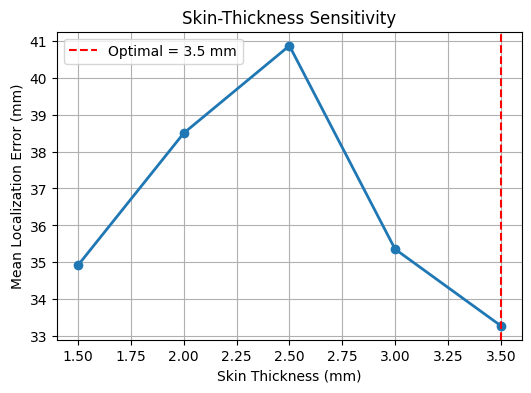

Data-driven optimal skin thickness (mm): 3.5


In [26]:
# ============================================================
# Skin-Thickness Parameter Sweep (data-driven, not literature-only)
# ============================================================
SENS_SUBSET = list(range(min(25, N_VALID_SCANS)))
SKIN_THICKNESS_SWEEP = [1.5, 2.0, 2.5, 3.0, 3.5]

skin_sweep_error = []
for st in SKIN_THICKNESS_SWEEP:
    errs = []
    for idx in SENS_SUBSET:
        try:
            r = reconstruct_scan_v2(idx, skin_thickness_mm=st, use_gt_tumor_layer=True)
            errs.append(r["localization_error_mm"])
        except Exception:
            pass
    skin_sweep_error.append(np.mean(errs) if errs else np.nan)

best_skin_thickness = SKIN_THICKNESS_SWEEP[int(np.nanargmin(skin_sweep_error))]

plt.figure(figsize=(6, 4))
plt.plot(SKIN_THICKNESS_SWEEP, skin_sweep_error, "o-", linewidth=2)
plt.axvline(best_skin_thickness, color="red", linestyle="--",
            label=f"Optimal = {best_skin_thickness} mm")
plt.xlabel("Skin Thickness (mm)")
plt.ylabel("Mean Localization Error (mm)")
plt.title("Skin-Thickness Sensitivity")
plt.legend()
plt.grid(True)
plt.show()

print("Data-driven optimal skin thickness (mm):", best_skin_thickness)


# **PHASE 5.7: SENSITIVITY ANALYSIS -- TUMOR & INTERIOR PERMITTIVITY**

In [ ]:
# ============================================================
# eps_tumor x eps_eff Joint Parameter Sweep (QUICK TEST)
# ============================================================
from joblib import Parallel, delayed

EPS_TUMOR_SWEEP = np.arange(40, 61, 5)
EPS_EFF_SWEEP = np.arange(15, 31, 3)

# ⚡ CUMA 5 SCAN DULU - ganti ke SENS_SUBSET kalau sudah yakin
QUICK_SUBSET = SENS_SUBSET[:5]

perm_error_grid = np.zeros((len(EPS_TUMOR_SWEEP), len(EPS_EFF_SWEEP)))

total = len(EPS_TUMOR_SWEEP) * len(EPS_EFF_SWEEP)
done = 0

for i, et in enumerate(EPS_TUMOR_SWEEP):
    for j, ee in enumerate(EPS_EFF_SWEEP):
        errs = []
        for idx in QUICK_SUBSET:
            try:
                r = reconstruct_scan_v2(idx, skin_thickness_mm=best_skin_thickness,
                                         eps_tumor=et, eps_eff_override=ee,
                                         use_gt_tumor_layer=True)
                errs.append(r["localization_error_mm"])
            except Exception as e:
                print(f"  ✗ idx={idx}: {e}", flush=True)

        perm_error_grid[i, j] = np.mean(errs) if errs else np.nan
        done += 1
        print(f"[{done}/{total}] et={et}, ee={ee} → err={perm_error_grid[i,j]:.2f} mm ({len(errs)}/{len(QUICK_SUBSET)} ok)", flush=True)

best_i, best_j = np.unravel_index(np.nanargmin(perm_error_grid), perm_error_grid.shape)
best_eps_tumor = float(EPS_TUMOR_SWEEP[best_i])
best_eps_eff = float(EPS_EFF_SWEEP[best_j])

plt.figure(figsize=(7, 5))
plt.imshow(perm_error_grid, aspect="auto", cmap="turbo",
           extent=[EPS_EFF_SWEEP[0], EPS_EFF_SWEEP[-1], EPS_TUMOR_SWEEP[-1], EPS_TUMOR_SWEEP[0]])
plt.colorbar(label="Mean Localization Error (mm)")
plt.scatter([best_eps_eff], [best_eps_tumor], c="red", marker="x", s=150,
            label=f"Best: eps_tumor={best_eps_tumor}, eps_eff={best_eps_eff}")
plt.xlabel("eps_eff (Interior)")
plt.ylabel("eps_tumor")
plt.title("Permittivity Sensitivity (Quick Test - 5 scans)")
plt.legend()
plt.show()

print("Data-driven optimal eps_tumor:", best_eps_tumor)
print("Data-driven optimal eps_eff  :", best_eps_eff)

[1/30] et=40, ee=15 → err=35.70 mm (5/5 ok)
[2/30] et=40, ee=18 → err=36.63 mm (5/5 ok)
[3/30] et=40, ee=21 → err=30.27 mm (5/5 ok)
[4/30] et=40, ee=24 → err=35.14 mm (5/5 ok)
[5/30] et=40, ee=27 → err=35.85 mm (5/5 ok)
[6/30] et=40, ee=30 → err=36.51 mm (5/5 ok)
[7/30] et=45, ee=15 → err=38.69 mm (5/5 ok)
[8/30] et=45, ee=18 → err=36.54 mm (5/5 ok)
[9/30] et=45, ee=21 → err=29.98 mm (5/5 ok)
[10/30] et=45, ee=24 → err=34.90 mm (5/5 ok)
[11/30] et=45, ee=27 → err=35.65 mm (5/5 ok)
[12/30] et=45, ee=30 → err=36.37 mm (5/5 ok)
[13/30] et=50, ee=15 → err=38.44 mm (5/5 ok)
[14/30] et=50, ee=18 → err=25.33 mm (5/5 ok)
[15/30] et=50, ee=21 → err=29.46 mm (5/5 ok)
[16/30] et=50, ee=24 → err=34.74 mm (5/5 ok)
[17/30] et=50, ee=27 → err=35.50 mm (5/5 ok)
[18/30] et=50, ee=30 → err=36.20 mm (5/5 ok)
[19/30] et=55, ee=15 → err=38.25 mm (5/5 ok)
[20/30] et=55, ee=18 → err=36.38 mm (5/5 ok)
[21/30] et=55, ee=21 → err=29.34 mm (5/5 ok)
[22/30] et=55, ee=24 → err=34.65 mm (5/5 ok)
[23/30] et=55, ee=2

# **PHASE 5.8: UPPER-BOUND BENCHMARKING & SELF-CALIBRATION FEEDBACK**

In [ ]:
# ============================================================
# V-Shape Baseline vs 3-Layer Full (GT-informed) Upper Bound
# ============================================================
# Quantifies how much of the ~45mm baseline error is attributable to
# the propagation model itself (vs beamforming/enhancement), using the
# GT tumor mask as a best-case oracle for the tumor permittivity zone.

baseline_errors = []
full3layer_errors = []

for idx in SENS_SUBSET:
    try:
        baseline_errors.append(reconstruct_scan(idx)["localization_error_mm"])
    except Exception:
        pass
    try:
        r = reconstruct_scan_v2(idx, skin_thickness_mm=best_skin_thickness,
                                 eps_tumor=best_eps_tumor, eps_eff_override=best_eps_eff,
                                 use_gt_tumor_layer=True)
        full3layer_errors.append(r["localization_error_mm"])
    except Exception:
        pass

print("V-Shape baseline   -- mean error (mm):", np.mean(baseline_errors))
print("3-Layer Full (GT)  -- mean error (mm):", np.mean(full3layer_errors))
print("Max potential improvement from propagation-model correction (mm):",
      np.mean(baseline_errors) - np.mean(full3layer_errors))


In [ ]:
# ============================================================
# Feed Best Sensitivity-Analysis Parameters Back Into the Pipeline
# ============================================================
# Turns the 3-Layer model from a theoretical best-case demo into a
# self-calibrated reconstruction framework: every future call to
# reconstruct_scan_v2() (with its default arguments) now automatically
# uses these empirically-optimal values instead of hardcoded literature
# constants.

CALIBRATED_PARAMS["skin_thickness_mm"] = float(best_skin_thickness)
CALIBRATED_PARAMS["eps_tumor"] = float(best_eps_tumor)
CALIBRATED_PARAMS["eps_eff_calibrated"] = float(best_eps_eff)

print("Pipeline calibrated with data-driven parameters:")
print(CALIBRATED_PARAMS)
print()
print("NOTE: eps_eff_calibrated is a GLOBAL override. If you'd rather keep")
print("each phantom's own fat/fibro-fraction-derived eps_eff, set")
print("CALIBRATED_PARAMS['eps_eff_calibrated'] = None before batch runs.")


# **PHASE 6: SINGLE-SCAN DEMO**

In [ ]:
# ============================================================
# Run One Scan (Full Diagnostics)
# ============================================================

DEMO_SCAN_IDX = 0

demo = reconstruct_scan(DEMO_SCAN_IDX, return_diagnostics=True)
diag = demo["diagnostics"]

print("Phantom              :", demo["phant_id"])
print("Breast Radius (mm)   :", demo["breast_radius_mm"])
print("Wave Velocity (m/s)  :", demo["wave_velocity"])
print("TVSVD Rank Removed   :", demo["tvsvd_rank_removed"])
print("Blob Threshold Used  :", demo["blob_threshold_used"])
print("Localization Error   :", demo["localization_error_mm"], "mm")
print("IoU / Dice            :", demo["iou"], demo["dice"])
print("SCR / SMR / CNR        :", demo["scr_db"], demo["smr_db"], demo["cnr"])
print("Peak Intensity        :", demo["peak_intensity"])
print("Runtime (s)            :", demo["runtime_sec"])

Phantom              : A13F14
Breast Radius (mm)   : 43.8
Wave Velocity (m/s)  : 72303359.94694692
TVSVD Rank Removed   : 5
Blob Threshold Used  : 0.40297315218510166
Localization Error   : 19.72485607250044 mm
IoU / Dice            : 0.00849575212393803 0.01684836471754212
SCR / SMR / CNR        : 5.139209003389313 4.676910334700024 2.8311851814803872
Peak Intensity        : 137.64656548559478
Runtime (s)            : 0.09762880000016594


Injected pixel  : 15.0 -10.0
Recovered pixel : 13.618487394957981 -18.771428571428572
Error (mm)      : 8.879557210895342


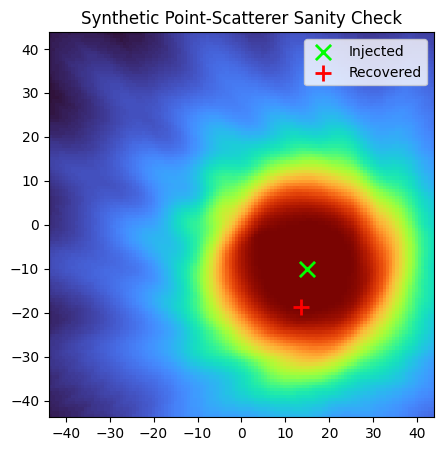

In [ ]:
# ============================================================
# SANITY CHECK: Synthetic Point-Scatterer Recovery
# ============================================================
# Inject a delayed impulse at a KNOWN pixel into a synthetic
# multi-channel time signal (using this scan's real geometry/
# velocity), run it through the exact same align+DAS path used
# by reconstruct_scan, and check whether the recovered peak lands
# on the injected pixel. If it does NOT, the bug is in TOF/geometry
# (systematic). If it DOES, the bug is downstream (TVSVD, threshold,
# or the real data itself) -- not the geometry.

target_x_mm, target_y_mm = 15.0, -10.0   # pick any point inside the grid

r = demo["breast_radius_mm"]
nx, ny = 120, 120
x_axis_chk = np.linspace(-r, r, nx)
y_axis_chk = np.linspace(-r, r, ny)

# rebuild this scan's delay grid the exact same way reconstruct_scan does
grid_x_chk, grid_y_chk = np.meshgrid(x_axis_chk, y_axis_chk)
ant_x = antenna_geometry["x_mm"].values
ant_y = antenna_geometry["y_mm"].values
tx_idx = channel_map["tx"].values
rx_idx = channel_map["rx"].values

dist_tx = np.sqrt((grid_x_chk.ravel()[None,:]-ant_x[tx_idx,None])**2
                   + (grid_y_chk.ravel()[None,:]-ant_y[tx_idx,None])**2)
dist_rx = np.sqrt((grid_x_chk.ravel()[None,:]-ant_x[rx_idx,None])**2
                   + (grid_y_chk.ravel()[None,:]-ant_y[rx_idx,None])**2)
delay_grid_chk = ((dist_tx+dist_rx)/1000) / demo["wave_velocity"]

# true one-way-sum delay to the injected target, per channel
dist_tx_t = np.sqrt((target_x_mm-ant_x[tx_idx])**2 + (target_y_mm-ant_y[tx_idx])**2)
dist_rx_t = np.sqrt((target_x_mm-ant_x[rx_idx])**2 + (target_y_mm-ant_y[rx_idx])**2)
target_delay = ((dist_tx_t+dist_rx_t)/1000) / demo["wave_velocity"]

synth_signal = np.zeros((len(time), len(tx_idx)), dtype=complex)
pulse_width = 3   # samples
for ch in range(len(tx_idx)):
    center = np.argmin(np.abs(time - target_delay[ch]))
    lo, hi = max(0,center-pulse_width), min(len(time),center+pulse_width)
    synth_signal[lo:hi, ch] = 1.0

synth_aligned = align_channels(synth_signal, delay_grid_chk, time)
synth_img = beamform_das(synth_aligned).reshape(ny, nx)

recovered_idx = np.unravel_index(np.argmax(synth_img), synth_img.shape)
recovered_x = x_axis_chk[recovered_idx[1]]
recovered_y = y_axis_chk[recovered_idx[0]]

print("Injected pixel  :", target_x_mm, target_y_mm)
print("Recovered pixel :", recovered_x, recovered_y)
print("Error (mm)      :", np.hypot(recovered_x-target_x_mm, recovered_y-target_y_mm))

plt.figure(figsize=(6,5))
plt.imshow(synth_img, extent=[-r,r,-r,r], cmap="turbo", origin="lower")
plt.scatter([target_x_mm],[target_y_mm], c="lime", marker="x", s=120, linewidths=2, label="Injected")
plt.scatter([recovered_x],[recovered_y], c="red", marker="+", s=120, linewidths=2, label="Recovered")
plt.legend()
plt.title("Synthetic Point-Scatterer Sanity Check")
plt.show()

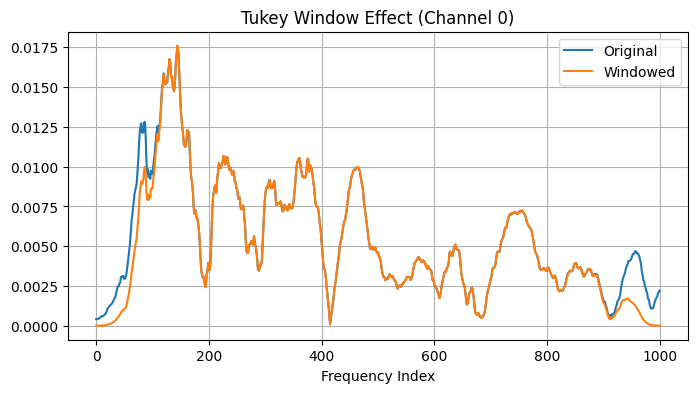

In [ ]:
# ============================================================
# Windowing Comparison
# ============================================================

plt.figure(figsize=(8,4))
plt.plot(np.abs(s21[DEMO_SCAN_IDX,:,0]), label="Original")
plt.plot(np.abs(diag["s21_window"][:,0]), label="Windowed")
plt.title("Tukey Window Effect (Channel 0)")
plt.xlabel("Frequency Index")
plt.legend()
plt.grid(True)
plt.show()

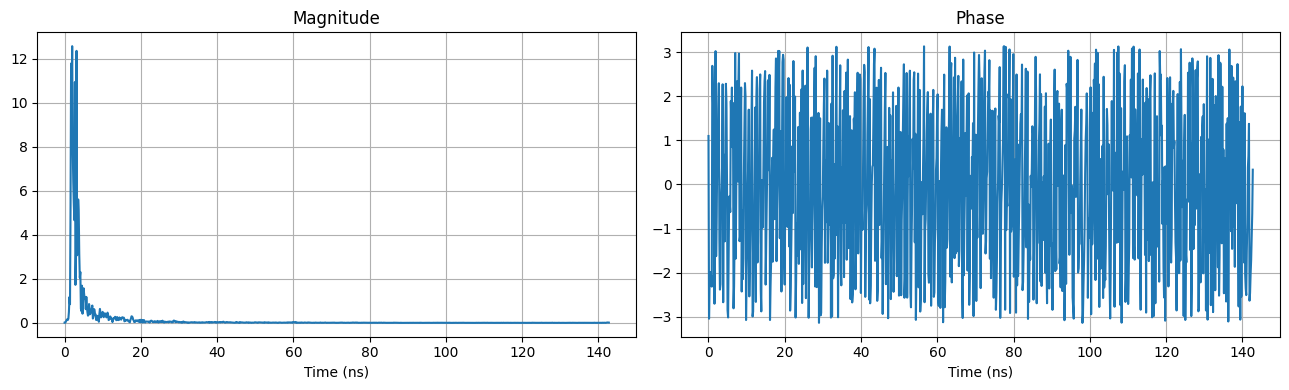

In [ ]:
# ============================================================
# Raw Time Signal (Magnitude & Phase)
# ============================================================

channel = 0

fig, ax = plt.subplots(1, 2, figsize=(13,4))

ax[0].plot(time*1e9, np.abs(diag["time_signal"][:,channel]))
ax[0].set_title("Magnitude")
ax[0].set_xlabel("Time (ns)")
ax[0].grid(True)

ax[1].plot(time*1e9, np.angle(diag["time_signal"][:,channel]))
ax[1].set_title("Phase")
ax[1].set_xlabel("Time (ns)")
ax[1].grid(True)

plt.tight_layout()
plt.show()

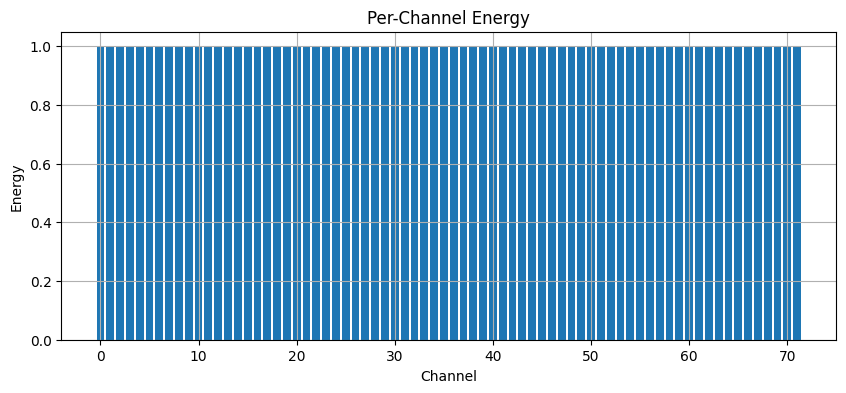

In [ ]:
# ============================================================
# Channel Energy Check
# ============================================================

plt.figure(figsize=(10,4))
plt.bar(np.arange(len(diag["channel_energy"])), diag["channel_energy"])
plt.xlabel("Channel")
plt.ylabel("Energy")
plt.title("Per-Channel Energy")
plt.grid(True)
plt.show()

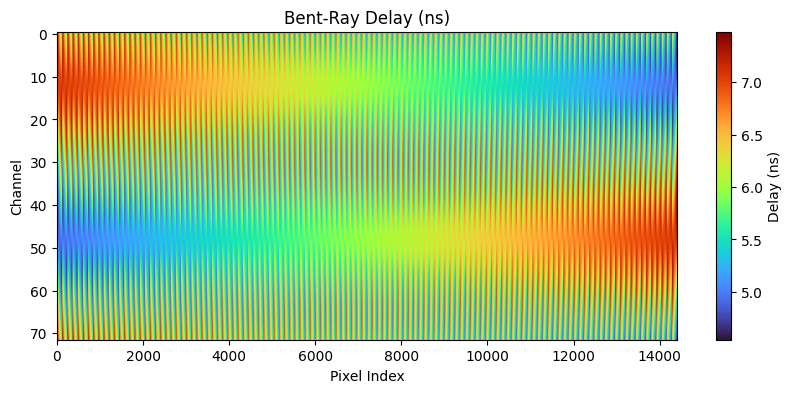

In [ ]:
# ============================================================
# Bent-Ray Delay Heatmap
# ============================================================

plt.figure(figsize=(10,4))
plt.imshow(diag["delay_grid"]*1e9, aspect="auto", cmap="turbo")
plt.xlabel("Pixel Index")
plt.ylabel("Channel")
plt.title("Bent-Ray Delay (ns)")
plt.colorbar(label="Delay (ns)")
plt.show()

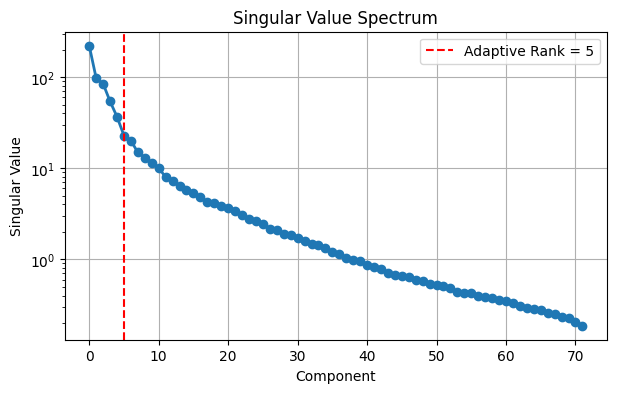

In [ ]:
# ============================================================
# TVSVD: Singular Value Spectrum (Adaptive Rank)
# ============================================================

S = diag["singular_values"]
remove = demo["tvsvd_rank_removed"]

plt.figure(figsize=(7,4))
plt.semilogy(S, 'o-', linewidth=2)
plt.axvline(remove, color='red', linestyle='--', label=f'Adaptive Rank = {remove}')
plt.title("Singular Value Spectrum")
plt.xlabel("Component")
plt.ylabel("Singular Value")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_24332\3397297453.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


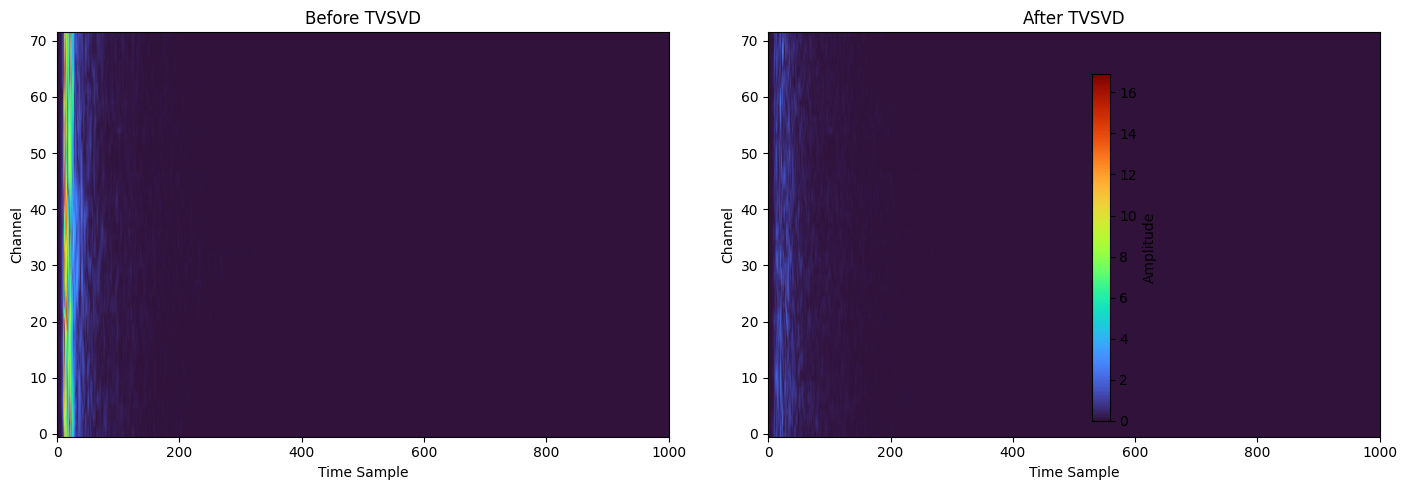

In [ ]:
# ============================================================
# TVSVD Before vs After (Heatmap)
# ============================================================

X = diag["time_signal"]
X_tsvd = diag["time_signal_tsvd"]

fig, ax = plt.subplots(1, 2, figsize=(14,5))
vmin, vmax = 0, max(np.abs(X).max(), np.abs(X_tsvd).max())

im1 = ax[0].imshow(np.abs(X.T), aspect="auto", origin="lower", cmap="turbo", vmin=vmin, vmax=vmax)
ax[0].set_title("Before TVSVD")
ax[0].set_xlabel("Time Sample")
ax[0].set_ylabel("Channel")

im2 = ax[1].imshow(np.abs(X_tsvd.T), aspect="auto", origin="lower", cmap="turbo", vmin=vmin, vmax=vmax)
ax[1].set_title("After TVSVD")
ax[1].set_xlabel("Time Sample")
ax[1].set_ylabel("Channel")

cbar = fig.colorbar(im2, ax=ax.ravel().tolist(), shrink=0.9)
cbar.set_label("Amplitude")
plt.tight_layout()
plt.show()

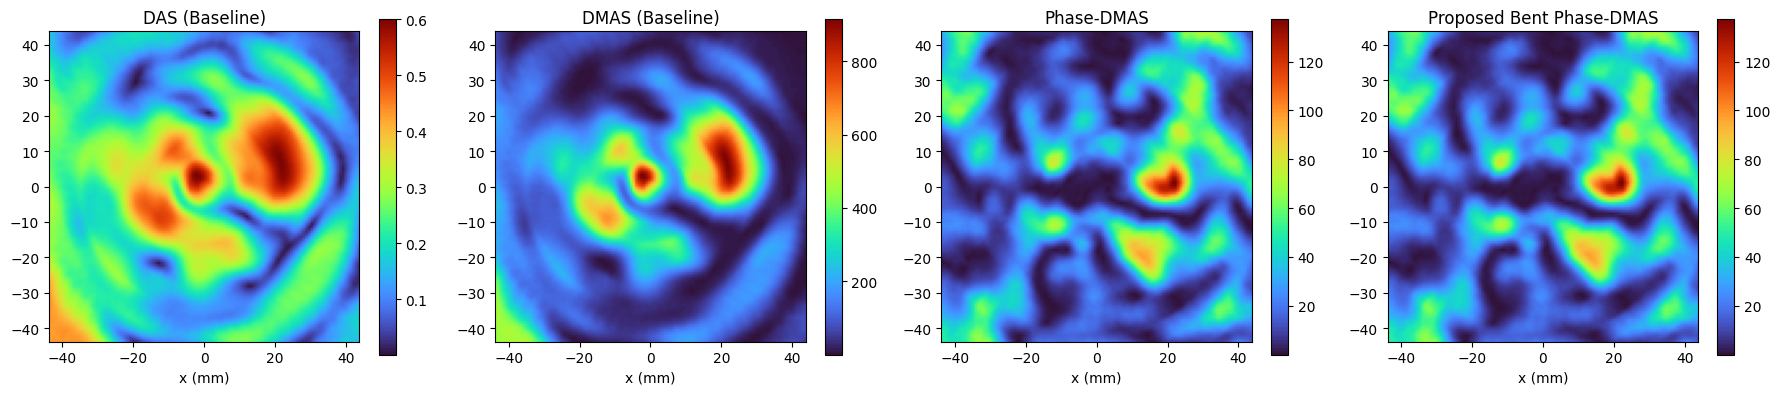

In [ ]:
# ============================================================
# DAS / DMAS / Phase-DMAS / Proposed (Individual Images)
# ============================================================

r = demo["breast_radius_mm"]
imgs = demo["images"]

fig, axes = plt.subplots(1, 4, figsize=(18,4.5))
titles = ["DAS (Baseline)", "DMAS (Baseline)", "Phase-DMAS", "Proposed Bent Phase-DMAS"]
keys = ["das", "dmas", "phase_dmas", "bent_phase_dmas"]

for ax, title, key in zip(axes, titles, keys):
    im = ax.imshow(imgs[key], extent=[-r,r,-r,r], cmap="turbo", origin="lower")
    ax.set_title(title)
    ax.set_xlabel("x (mm)")
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

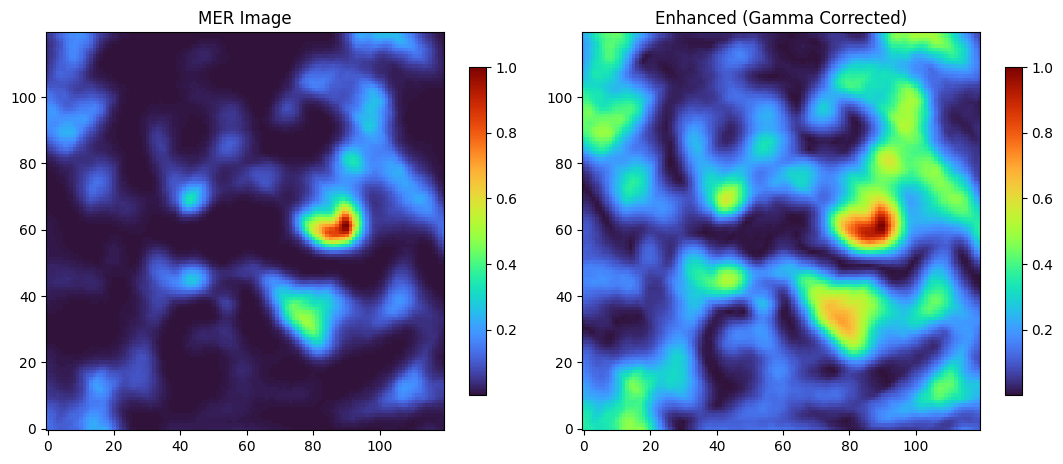

In [ ]:
# ============================================================
# MER & Contrast Enhancement
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(11,4.5))

im1 = ax[0].imshow(imgs["mer"], cmap="turbo", origin="lower")
ax[0].set_title("MER Image")
fig.colorbar(im1, ax=ax[0], shrink=0.8)

im2 = ax[1].imshow(imgs["enhanced"], cmap="turbo", origin="lower")
ax[1].set_title("Enhanced (Gamma Corrected)")
fig.colorbar(im2, ax=ax[1], shrink=0.8)

plt.tight_layout()
plt.show()

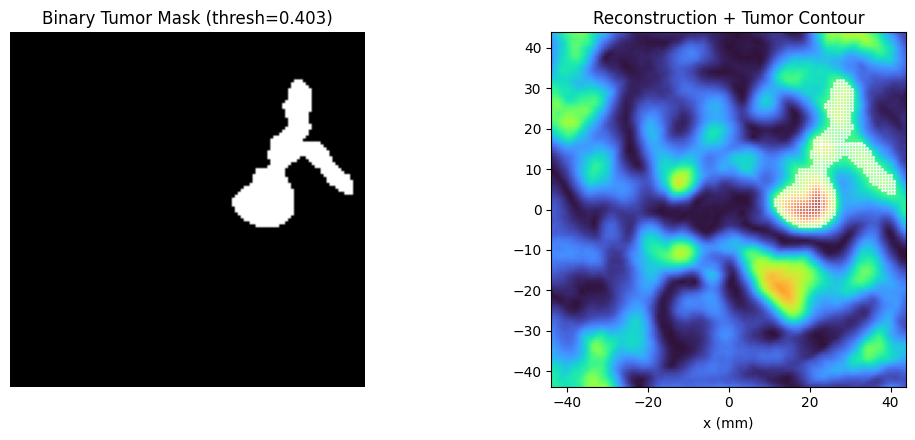

In [ ]:
# ============================================================
# Blob Mask & Boundary Overlay
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(11,4.5))

ax[0].imshow(imgs["tumor_mask"], cmap="gray", origin="lower")
ax[0].set_title(f"Binary Tumor Mask (thresh={demo['blob_threshold_used']:.3f})")
ax[0].axis("off")

ax[1].imshow(imgs["enhanced"], extent=[-r,r,-r,r], cmap="turbo", origin="lower")
ys, xs = np.where(imgs["tumor_mask"])
if len(xs) > 0:
    ax[1].scatter(demo["x_axis"][xs], demo["y_axis"][ys], s=1, c="white")
ax[1].set_title("Reconstruction + Tumor Contour")
ax[1].set_xlabel("x (mm)")

plt.tight_layout()
plt.show()

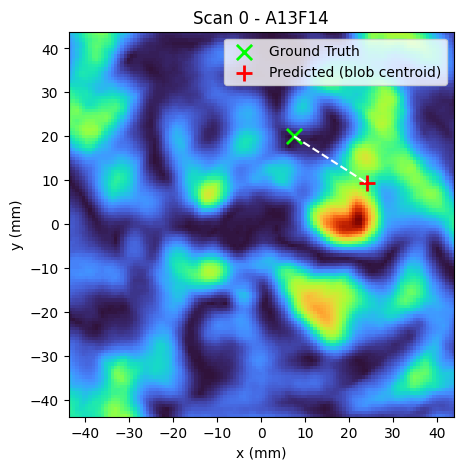

In [ ]:
# ============================================================
# Predicted vs Ground Truth (Single Scan)
# ============================================================

plt.figure(figsize=(6,5))
plt.imshow(imgs["enhanced"], extent=[-r,r,-r,r], cmap="turbo", origin="lower")
plt.scatter([demo["gt_x_mm"]], [demo["gt_y_mm"]], c="lime", marker="x",
            s=120, linewidths=2, label="Ground Truth")
plt.scatter([demo["peak_x_mm"]], [demo["peak_y_mm"]], c="red", marker="+",
            s=120, linewidths=2, label="Predicted (blob centroid)")
plt.plot([demo["gt_x_mm"],demo["peak_x_mm"]], [demo["gt_y_mm"],demo["peak_y_mm"]],
         c="white", linestyle="--")
plt.legend()
plt.title(f"Scan {demo['scan_idx']} - {demo['phant_id']}")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.show()

# **PHASE 7: BATCH PROCESSING**

In [ ]:
# ============================================================
# Run reconstruct_scan Over Many Scans
# ============================================================
# Set to N_VALID_SCANS to process everything available. Lower this
# only if you need a quick smoke-test run.

N_SCANS_BATCH = N_VALID_SCANS

batch_results = {}
batch_rows = []
failed_scans = []

for idx in range(N_SCANS_BATCH):
    try:
        result = reconstruct_scan(idx)
        batch_results[idx] = result
        batch_rows.append({
            "scan_idx": idx,
            "phant_id": result["phant_id"],
            "breast_radius_mm": result["breast_radius_mm"],
            "localization_error_mm": result["localization_error_mm"],
            "iou": result["iou"],
            "dice": result["dice"],
            "scr_db": result["scr_db"],
            "smr_db": result["smr_db"],
            "cnr": result["cnr"],
            "peak_intensity": result["peak_intensity"],
            "tvsvd_rank_removed": result["tvsvd_rank_removed"],
            "blob_threshold_used": result["blob_threshold_used"],
            "runtime_sec": result["runtime_sec"],
        })
    except Exception as e:
        failed_scans.append((idx, str(e)))

    if (idx+1) % 20 == 0 or (idx+1) == N_SCANS_BATCH:
        print(f"Processed {idx+1}/{N_SCANS_BATCH}")

batch_metrics_df = pd.DataFrame(batch_rows)

print("Processed :", len(batch_results), "/", N_SCANS_BATCH)
print("Failed    :", failed_scans)
display(batch_metrics_df.head())

Processed 20/432
Processed 40/432
Processed 60/432
Processed 80/432
Processed 100/432
Processed 120/432
Processed 140/432
Processed 160/432
Processed 180/432
Processed 200/432
Processed 220/432
Processed 240/432
Processed 260/432
Processed 280/432
Processed 300/432
Processed 320/432
Processed 340/432
Processed 360/432
Processed 380/432
Processed 400/432
Processed 420/432
Processed 432/432
Processed : 432 / 432
Failed    : []


,scan_idx,phant_id,breast_radius_mm,localization_error_mm,iou,dice,scr_db,smr_db,cnr,peak_intensity,tvsvd_rank_removed,blob_threshold_used,runtime_sec
0,0,A13F14,43.8,19.724856,0.008496,0.016848,5.139209,4.676910,2.831185,137.646565,5,0.402973,0.086395
1,1,A13F14,43.8,29.886072,0.000000,0.000000,6.155547,5.579775,2.923486,131.788404,5,0.386459,0.091793
2,2,A13F14,43.8,64.566685,0.000000,0.000000,6.518509,5.696299,4.429515,145.853171,6,0.325780,0.087164
3,3,A13F14,43.8,45.851170,0.000000,0.000000,6.591046,5.856589,3.488492,124.201679,5,0.430795,0.087119
4,4,A13F14,43.8,39.230380,0.000000,0.000000,6.086945,5.679189,3.564306,154.438845,5,0.356315,0.088130


# **PHASE 7.5: BATCH PROCESSING -- SELF-CALIBRATED 3-LAYER PIPELINE**

In [ ]:
# ============================================================
# Run reconstruct_scan_v2 Over Many Scans (No GT Leakage)
# ============================================================
# use_gt_tumor_layer=False here -- inference must not use the ground
# truth tumor mask inside the forward model. Only the calibrated
# skin_thickness_mm / eps_tumor / eps_eff from Phase 5.6-5.8 are used.

N_SCANS_BATCH_V2 = N_VALID_SCANS

batch_results_v2 = {}
batch_rows_v2 = []
failed_scans_v2 = []

for idx in range(N_SCANS_BATCH_V2):
    try:
        result = reconstruct_scan_v2(idx, use_gt_tumor_layer=False)
        batch_results_v2[idx] = result
        batch_rows_v2.append({
            "scan_idx": idx,
            "phant_id": result["phant_id"],
            "breast_radius_mm": result["breast_radius_mm"],
            "antenna_radius_mm": result["antenna_radius_mm"],
            "localization_error_mm": result["localization_error_mm"],
            "iou": result["iou"],
            "dice": result["dice"],
            "scr_db": result["scr_db"],
            "smr_db": result["smr_db"],
            "cnr": result["cnr"],
            "peak_intensity": result["peak_intensity"],
            "tvsvd_rank_removed": result["tvsvd_rank_removed"],
            "blob_threshold_used": result["blob_threshold_used"],
            "runtime_sec": result["runtime_sec"],
        })
    except Exception as e:
        failed_scans_v2.append((idx, str(e)))

    if (idx+1) % 20 == 0 or (idx+1) == N_SCANS_BATCH_V2:
        print(f"Processed {idx+1}/{N_SCANS_BATCH_V2}")

batch_metrics_df_v2 = pd.DataFrame(batch_rows_v2)

print("Processed :", len(batch_results_v2), "/", N_SCANS_BATCH_V2)
print("Failed    :", failed_scans_v2)
display(batch_metrics_df_v2.head())


In [ ]:
# ============================================================
# Baseline (V-Shape) vs Self-Calibrated 3-Layer -- Full-Batch Comparison
# ============================================================
comparison = pd.DataFrame({
    "V-Shape Baseline": [
        batch_metrics_df["localization_error_mm"].mean(),
        batch_metrics_df["iou"].mean(),
        batch_metrics_df["dice"].mean(),
        batch_metrics_df["scr_db"].mean(),
    ],
    "3-Layer Self-Calibrated": [
        batch_metrics_df_v2["localization_error_mm"].mean(),
        batch_metrics_df_v2["iou"].mean(),
        batch_metrics_df_v2["dice"].mean(),
        batch_metrics_df_v2["scr_db"].mean(),
    ],
}, index=["Mean Localization Error (mm)", "Mean IoU", "Mean Dice", "Mean SCR (dB)"])

display(comparison)


# **PHASE 8: QUANTITATIVE EVALUATION**

In [ ]:
# ============================================================
# Aggregate Metrics
# ============================================================

print("Mean Localization Error (mm):", batch_metrics_df["localization_error_mm"].mean())
print("Mean IoU                    :", batch_metrics_df["iou"].mean())
print("Mean Dice                   :", batch_metrics_df["dice"].mean())
print("Mean SCR (dB)                :", batch_metrics_df["scr_db"].mean())
print("Detection Rate (<=20mm)      :",
      (batch_metrics_df["localization_error_mm"]<=20).mean())

Mean Localization Error (mm): 45.50937668860875
Mean IoU                    : 0.014935989011425095
Mean Dice                   : 0.024157315514931624
Mean SCR (dB)                : 6.033995328888498
Detection Rate (<=20mm)      : 0.13657407407407407


tum_in_fib
0.0    44.778160
1.0    44.673191
Name: localization_error_mm, dtype: float64

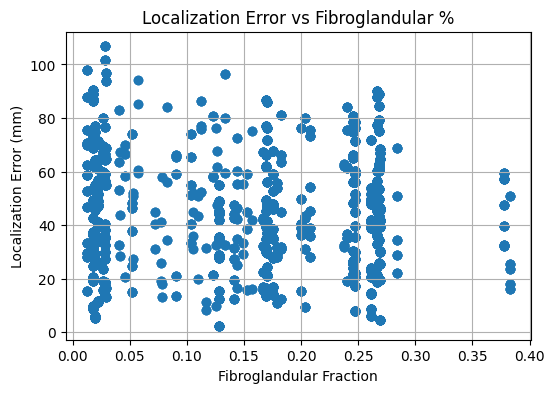

In [ ]:
# ============================================================
# Metadata-Grouped Analysis
# ============================================================

eval_df = batch_metrics_df.merge(
    tumor_model[["phant_id","fib_fraction","tum_in_fib"]],
    on="phant_id", how="left"
)

display(
    eval_df.groupby("tum_in_fib")["localization_error_mm"].mean()
)

plt.figure(figsize=(6,4))
plt.scatter(eval_df["fib_fraction"], eval_df["localization_error_mm"])
plt.xlabel("Fibroglandular Fraction")
plt.ylabel("Localization Error (mm)")
plt.title("Localization Error vs Fibroglandular %")
plt.grid(True)
plt.show()

# **PHASE 9: ALGORITHM FUSION**

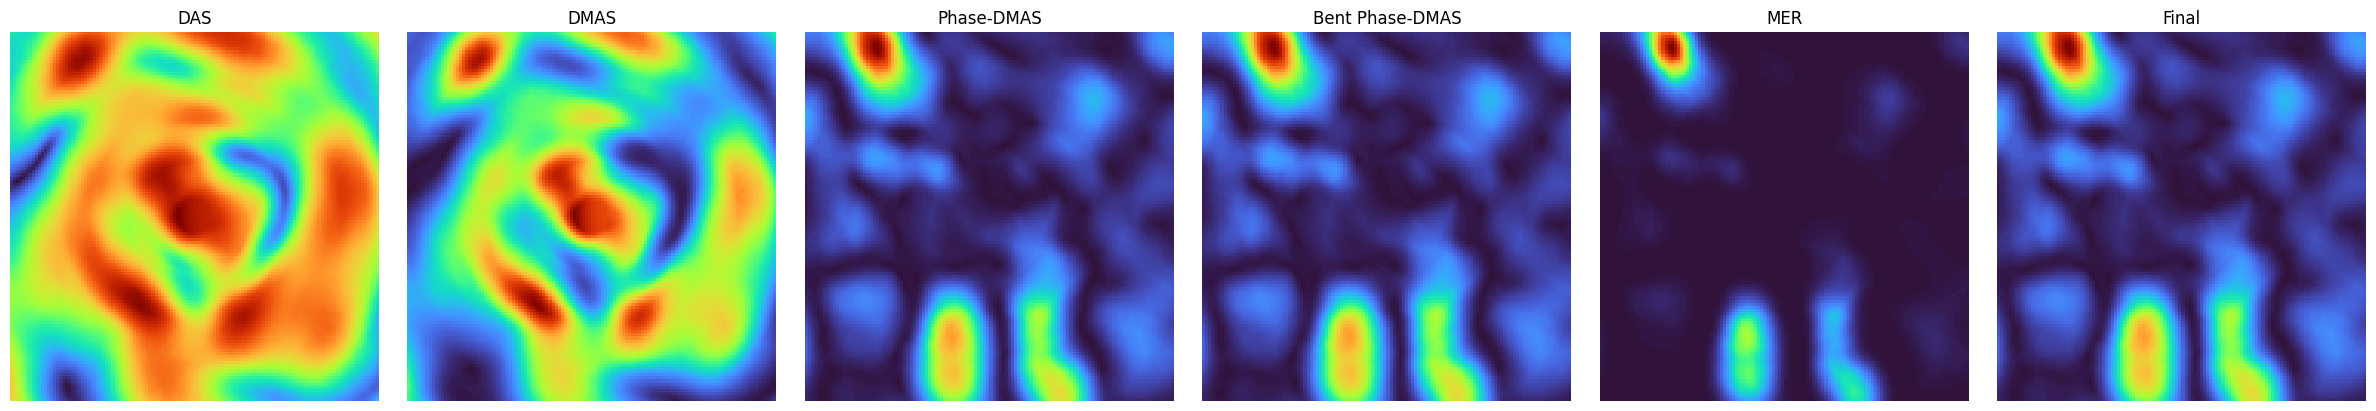

In [ ]:
# ============================================================
# Algorithm Comparison (One Selected Scan From Batch)
# ============================================================

fusion_scan_idx = batch_metrics_df.iloc[
    batch_metrics_df["localization_error_mm"].idxmin()
]["scan_idx"]

fusion_result = batch_results[int(fusion_scan_idx)]
imgs = fusion_result["images"]

panel = {
    "DAS": imgs["das"], "DMAS": imgs["dmas"],
    "Phase-DMAS": imgs["phase_dmas"],
    "Bent Phase-DMAS": imgs["bent_phase_dmas"],
    "MER": imgs["mer"], "Final": imgs["enhanced"],
}

fig, axes = plt.subplots(1, len(panel), figsize=(4*len(panel),4))
for ax, (name,img) in zip(axes, panel.items()):
    ax.imshow(img, cmap="turbo", origin="lower")
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

# **PHASE 10: FINAL VISUALIZATION & EXPORT (ISOLATED)**

In [ ]:
# ============================================================
# Isolated From Phase 1-9 Pipeline Logic
# ============================================================
# Only reads pre-computed dictionaries (batch_results,
# batch_metrics_df) built in Phase 7. No signal is reprocessed
# here -- pure reporting / export.

assert "batch_results" in globals(), "Run Phase 7 first."
assert "batch_metrics_df" in globals(), "Run Phase 7 first."

print("Scans available for export:", list(batch_results.keys()))

Scans available for export: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 2

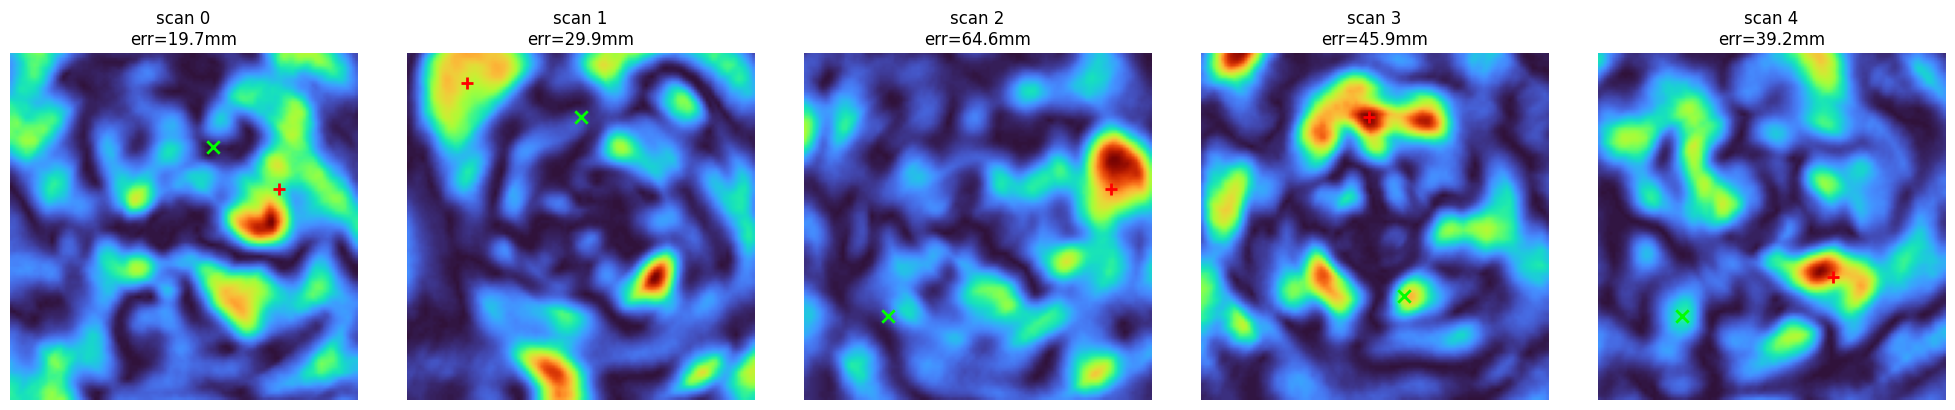

In [ ]:
# ============================================================
# Show 5 Sample Scans (Predicted vs Ground Truth)
# ============================================================
# Still isolated: reads only batch_results, nothing recomputed.

EXPORT_SCAN_IDS = list(batch_results.keys())[:5]

fig, axes = plt.subplots(1, len(EXPORT_SCAN_IDS), figsize=(4*len(EXPORT_SCAN_IDS),4))
if len(EXPORT_SCAN_IDS) == 1:
    axes = [axes]

for ax, idx in zip(axes, EXPORT_SCAN_IDS):
    result = batch_results[idx]
    r = result["breast_radius_mm"]
    ax.imshow(result["images"]["enhanced"], extent=[-r,r,-r,r],
               cmap="turbo", origin="lower")
    ax.scatter([result["gt_x_mm"]], [result["gt_y_mm"]], c="lime", marker="x", s=80, linewidths=2)
    ax.scatter([result["peak_x_mm"]], [result["peak_y_mm"]], c="red", marker="+", s=80, linewidths=2)
    ax.set_title(f"scan {idx}\nerr={result['localization_error_mm']:.1f}mm")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Export Selected Scans to Disk
# ============================================================

for idx in EXPORT_SCAN_IDS:

    result = batch_results[idx]
    out_dir = Path("results")/f"scan_{result['scan_idx']:03d}"
    out_dir.mkdir(parents=True, exist_ok=True)

    export_map = {
        "01_das.png": result["images"]["das"],
        "02_dmas.png": result["images"]["dmas"],
        "03_phase_dmas.png": result["images"]["phase_dmas"],
        "04_bent_phase_dmas.png": result["images"]["bent_phase_dmas"],
        "05_mer.png": result["images"]["mer"],
        "06_final.png": result["images"]["enhanced"],
    }

    for filename, img in export_map.items():
        plt.figure(figsize=(6,5))
        plt.imshow(img, cmap="turbo", origin="lower")
        plt.axis("off")
        plt.savefig(out_dir/filename, bbox_inches="tight")
        plt.close()

    pd.DataFrame([{
        "scan_idx": result["scan_idx"],
        "phant_id": result["phant_id"],
        "localization_error_mm": result["localization_error_mm"],
        "iou": result["iou"], "dice": result["dice"],
        "scr_db": result["scr_db"], "cnr": result["cnr"],
    }]).to_csv(out_dir/"metrics.csv", index=False)

batch_metrics_df.to_csv(Path("results")/"summary_metrics.csv", index=False)

print("Exported", len(EXPORT_SCAN_IDS), "scans to results/")

Exported 5 scans to results/


In [ ]:
# ============================================================
# Overall Accuracy Metrics (Full Batch, Isolated Report)
# ============================================================

print("Scans evaluated              :", len(batch_metrics_df))
print("Mean Localization Error (mm) :", batch_metrics_df["localization_error_mm"].mean())
print("Median Localization Error(mm):", batch_metrics_df["localization_error_mm"].median())
print("Mean IoU                     :", batch_metrics_df["iou"].mean())
print("Mean Dice                    :", batch_metrics_df["dice"].mean())
print("Mean SCR (dB)                 :", batch_metrics_df["scr_db"].mean())
print("Mean SMR (dB)                 :", batch_metrics_df["smr_db"].mean())
print("Mean Peak Intensity           :", batch_metrics_df["peak_intensity"].mean())
print("Mean TVSVD Rank Removed       :", batch_metrics_df["tvsvd_rank_removed"].mean())
print("Detection Rate (<=20mm)       :", (batch_metrics_df["localization_error_mm"]<=20).mean())

display(batch_metrics_df.describe())

Scans evaluated              : 432
Mean Localization Error (mm) : 45.50937668860875
Median Localization Error(mm): 44.181624043967055
Mean IoU                     : 0.014935989011425095
Mean Dice                    : 0.024157315514931624
Mean SCR (dB)                 : 6.033995328888498
Mean SMR (dB)                 : 5.5894456383497575
Mean Peak Intensity           : 228.8611613880235
Mean TVSVD Rank Removed       : 5.856481481481482
Detection Rate (<=20mm)       : 0.13657407407407407


,scan_idx,breast_radius_mm,localization_error_mm,iou,dice,scr_db,smr_db,cnr,peak_intensity,tvsvd_rank_removed,blob_threshold_used,runtime_sec
count,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000,432.000000
mean,215.500000,47.216667,45.509377,0.014936,0.024157,6.033995,5.589446,3.283745,228.861161,5.856481,0.372821,0.098244
std,124.851912,8.324838,21.642994,0.059214,0.090942,0.783781,0.651249,0.815382,100.700300,0.860451,0.082215,0.007506
min,0.000000,33.100000,2.469915,0.000000,0.000000,4.471944,4.291751,1.252059,42.254342,4.000000,0.120060,0.083193
25%,107.750000,39.000000,29.374663,0.000000,0.000000,5.451913,5.110291,2.689133,160.472952,5.000000,0.314414,0.092459
50%,215.500000,45.400000,44.181624,0.000000,0.000000,5.991272,5.540085,3.161780,201.773826,6.000000,0.370287,0.097849
75%,323.250000,56.200000,60.816204,0.000000,0.000000,6.532861,6.027276,3.655154,275.238931,6.000000,0.432991,0.103889
max,431.000000,57.000000,107.007467,0.438417,0.609583,9.124595,7.830733,7.428500,642.466576,9.000000,0.691065,0.118619
